## Noise Cancellation Using Normalized Least Mean Squares Adaptive Filtering

### Description

I attempt to replicate the LMS filtering process that occurs in noise cancelling headphones.

In headphones, there is an external microphone listening to the noise from the environment, which is correlated with the noise combined with the signal played through the headphones. In this example, I use a clean electric guitar recording of "fairest of the seasons" by Nico and some random acoustic noise samples to simulate this setup. I use the guitar recording combined with acoustic noise as my input, and I use a scaled version of the acoustic noise as an example of what might come through the external microphone. 

The LMS filter is applied to the reference noise, and attempts to mirror the noise in the noisy signal 180 degrees out of phase. The number of taps and a scaling parameter for weight update can be adjusted. I use a 64 tap filter and a learning rate of 0.01.

When I combine the filter output with the noisy signal I notice that the noise is reduced, but the high frequency artifacts like fast sliding, tapping, or note onsets are still present. It's not perfect but it's a quick and easy implementation that has obvious results. I comment on the maximum frequency the filter would expect to eliminate and show a couple performance metrics. Nothing fancy!

I think the main difference between this set-up and a headphone set-up is the secondary path between the headphone output and the internal microphone used for error calculation and feedback. This path is physical, it includes the shifts in magnitude and phase from the DAC, the speaker, and the earcup. Typically the response of the secondary path is pre-modelled and accounted for when the error is read by the internal microphone, so I figured I would just ignore the secondary path considerations in this simple implementation.

### Imports and Audio Loading

In [ ]:
import numpy as np
import padasip as pa
import matplotlib.pyplot as plt
from scipy.io.wavfile import read
from scipy.io.wavfile import write
from scipy.signal import stft
import IPython.display as ipd
from scipy.signal import welch

In [150]:
# Load audio clips
rate, target_guitar = read("../clips/mine/fairest_of_the_seasons.wav")
# rate, noise = read("../clips/mine/open/acoustic_noise_1.wav")
rate, noise = read("../clips/samples/low_frequency_noise_4.wav")
# rate, noise = read("../clips/samples/high_frequency_noise.wav")
# rate, noise = read("../clips/samples/low_frequency_noise_6.wav")


# Convert to mono if stereo
if target_guitar.ndim > 1:
    target_guitar = target_guitar.mean(axis=1).astype(target_guitar.dtype)
if noise.ndim > 1:
    noise = noise.mean(axis=1).astype(noise.dtype)

# Normalize audio
# target_guitar = target_guitar / np.max(np.abs(target_guitar))
# noise = noise / np.max(np.abs(noise))

# Trim to same length
N_samples = min(len(target_guitar), len(noise)) # Number of samples to process
target_guitar = target_guitar[:N_samples]
noise = noise[:N_samples]

# Organize inputs
input = target_guitar + noise # Primary input (signal + noise)
ref = 1.2* noise # Reference input (noise correlated with noise in primary input)

/var/folders/yz/xcf27lrx69l4v_mqmrv7_z_80000gn/T/ipykernel_79119/3569331354.py:2: WavFileWarning: Chunk (non-data) not understood, skipping it.
  rate, target_guitar = read("../clips/mine/fairest_of_the_seasons.wav")
/var/folders/yz/xcf27lrx69l4v_mqmrv7_z_80000gn/T/ipykernel_79119/3569331354.py:4: WavFileWarning: Chunk (non-data) not understood, skipping it.
  rate, noise = read("../clips/samples/low_frequency_noise_4.wav")


### Create the Filter

In [151]:
# Initialize NLMS filter parameters
order = 64 # Number of filter taps
mu = 0.01 # Learning rate
eps = 1e-6 # Small constant to avoid division by zero
w_prev = np.zeros(order) # Initial weights
w = np.zeros((N_samples, order)) # To store weights over time
e = np.zeros(N_samples) # Error signal

# Run the filter
for n in range(order, N_samples):
    x_n = ref[n-order:n][::-1] # Input vector (most recent samples)
    y_n = np.dot(w_prev, x_n) # Filter output
    e[n] = input[n] - y_n # Error signal
    w_new = w_prev + mu * e[n] * x_n / (np.dot(x_n, x_n) + eps) # Update weights
    w[n, :] = w_new
    w_prev = w_new

### Audio Playback

In [130]:
# Play the original audio
print("Playing original audio...")
ipd.Audio(input, rate=rate)

Playing original audio...


In [ ]:
# Play the audio of the output
cleaned_audio = e
print("Playing cleaned audio...")
ipd.Audio(cleaned_audio, rate=rate)

Maximum attenuation of noise: -1.78 dB
Playing cleaned audio...


In [153]:
# Play the audio of the original minus the cleaned audio
print("Playing noise removed by the filter...")
ipd.Audio(input-cleaned_audio, rate=rate)

Playing noise removed by the filter...


I notice that the high frequency artifacts like fast sliding, tapping, or note onsets are still present. It's cool that the filter reduces a lot of the noise though.

### Performance Metrics and Various Plots

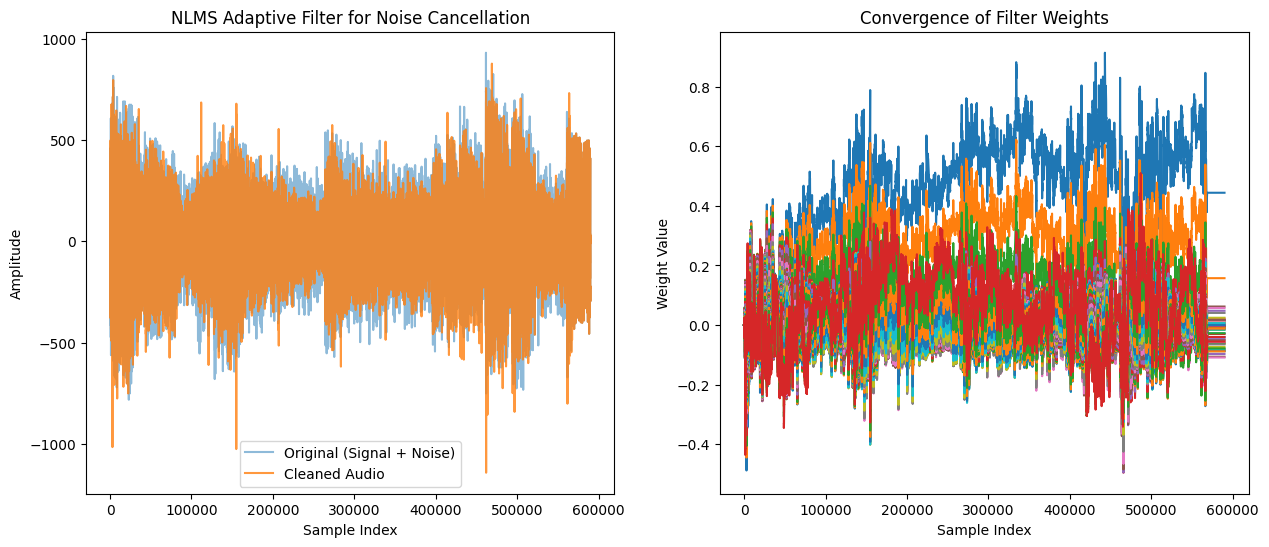

In [ ]:
# Calculate and print maximum attenuation of noise
max_attenuation = 20 * np.log10(np.max(np.abs(input)) / np.max(np.abs(e)))
print(f"Maximum attenuation of noise: {max_attenuation:.2f} dB")

# Plot results in time and weight convergence side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Plot results
ax1.plot(input, label="Original (Signal + Noise)", alpha=0.5)
ax1.plot(cleaned_audio, label="Cleaned Audio", alpha=0.8)
ax1.set_xlabel("Sample Index")
ax1.set_ylabel("Amplitude")
ax1.set_title("NLMS Adaptive Filter for Noise Cancellation")
ax1.legend()

# Plot weight convergence
for i in range(order):
    ax2.plot(w[:, i], label=f"Weight {i+1}")
ax2.set_xlabel("Sample Index")
ax2.set_ylabel("Weight Value")
ax2.set_title("Convergence of Filter Weights")
plt.show()

Estimated latency introduced by the filter: 1.4512 milliseconds
Maximum expected cancelled frequency: 172.27 Hz


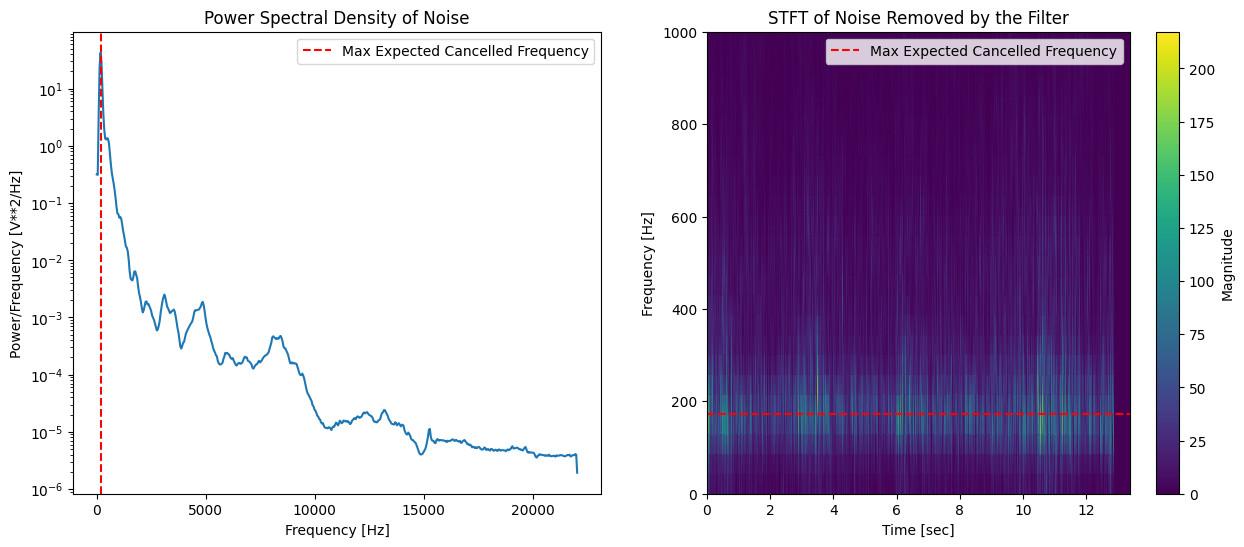

In [155]:
# Calculate and print expected performance metrics
latency = order / rate
print(f"Estimated latency introduced by the filter: {latency*1000:.4f} milliseconds")
max_expected_cancelled_freqency = 1 / (4 * latency)
print(f"Maximum expected cancelled frequency: {max_expected_cancelled_freqency:.2f} Hz")

# Plot frequency response of noise and stft of estimated noise side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Plot frequency response of the noise with a vertical red line at the max expected cancelled frequency
f_noise, Pxx_noise = welch(noise, fs=rate, nperseg=1024)
ax1.semilogy(f_noise, Pxx_noise)
ax1.axvline(x=max_expected_cancelled_freqency, color='r', linestyle='--', label='Max Expected Cancelled Frequency')
ax1.set_title('Power Spectral Density of Noise')
ax1.set_xlabel('Frequency [Hz]')
ax1.set_ylabel('Power/Frequency [V**2/Hz]')
ax1.legend()

# Plot an stft of the noise with a horizontal red line at the max expected cancelled frequency
f, t, Zxx = stft(input-cleaned_audio, fs=rate, nperseg=1024)
ax2.pcolormesh(t, f, np.abs(Zxx), shading='gouraud')
ax2.axhline(y=max_expected_cancelled_freqency, color='r', linestyle='--', label='Max Expected Cancelled Frequency')
ax2.set_title('STFT of Noise Removed by the Filter')
ax2.set_ylabel('Frequency [Hz]')
ax2.set_xlabel('Time [sec]')
ax2.set_ylim(0, 1000)
ax2.legend()
plt.colorbar(ax2.collections[0], ax=ax2, label='Magnitude')
plt.show()

### Write to File

In [ ]:
# Save the cleaned audio as a WAV file
cleaned_audio_int16 = np.int16(cleaned_audio / np.max(np.abs(cleaned_audio)) * 32767)
write("../clips/processed/cleaned_audio_1.wav", rate, cleaned_audio_int16)